# Cantilever with a composite laminate
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/shell/cantilever_laminate.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/shell/cantilever_laminate.ipynb)

A 100 mm x 50 mm x 1 mm cantilever plate, clamped at one end and loaded by
transverse forces at the two tip corners. The plate is made of a linear-elastic
cross-ply laminate.

The `Shell` measures ply angles from a global `orientation` (projected onto each
element), so we can sweep that reference direction to rotate the laminate's reference
direction and study how the tip deflection depends on the fiber angle.

## Material and laminate

In [1]:
import math

import matplotlib.pyplot as plt
import torch

from torchfem import Laminate, Shell
from torchfem.materials import OrthotropicElasticityPlaneStress
from torchfem.mesh import rect_tri

torch.set_default_dtype(torch.float64)

In [2]:
# Unidirectional GFRP
gfrp = OrthotropicElasticityPlaneStress(
    E_1=54000.0,
    E_2=9400.0,
    nu_12=0.33,
    G_12=5500.0,
    G_13=5500.0,
    G_23=3000.0,
    rho=1.8e-9,
)

# Cross-ply laminate
layup = Laminate(
    materials=[gfrp] * 4,
    thicknesses=[0.25] * 4,
    angles=[0.0, torch.pi / 2, torch.pi / 2, 0.0],
)

## Model setup

A reusable helper builds the clamped, tip-loaded cantilever for a given global
reference `orientation`.

In [3]:
nodes, elements = rect_tri(10, 5, Lx=100.0, Ly=50.0, variant="zigzag")
nodes = torch.hstack([nodes, torch.zeros((nodes.size(0), 1))])

left = nodes[:, 0] < 0.01
corner_1 = (nodes[:, 0] > 99.9) & (nodes[:, 1] < 0.01)
corner_2 = (nodes[:, 0] > 99.9) & (nodes[:, 1] > 49.99)


def cantilever(orientation):
    plate = Shell(nodes, elements, layup, orientation=orientation)
    plate.constraints[left] = True
    plate.forces[corner_1, 2] = -2.0
    plate.forces[corner_2, 2] = -2.0
    return plate

## Sweep the fiber orientation

Rotate the global reference direction (the 0° ply direction) from 0° to 180° and
record the maximum tip deflection for each angle.

In [4]:
angles = torch.linspace(0.0, 180.0, 19)
deflections = []
for angle in angles:
    # Build orientation vector from angle in degrees
    theta = math.radians(angle.item())
    orientation_vector = torch.tensor([math.cos(theta), math.sin(theta), 0.0])
    # Build cantilever problem and solve
    plate = cantilever(orientation_vector)
    u, _, _, _, _ = plate.solve()
    deflections.append(u[:, 2].abs().max().item())
deflections = torch.tensor(deflections)

## Visualization 

The deflection is minimal if the 0° outer plies are oriented with the plate. The maximum 
deflection does not occur at 90°, because a slight off-angle introduces twisting which 
increases the maximum deflection. 

In [5]:
# ABAQUS reference deflection (with S3 elements)
abq_half = [6.60, 8.09, 10.66, 13.85, 17.06, 19.68, 21.16, 21.60, 21.50, 21.13]
abq_deflection = abq_half + abq_half[-2::-1]

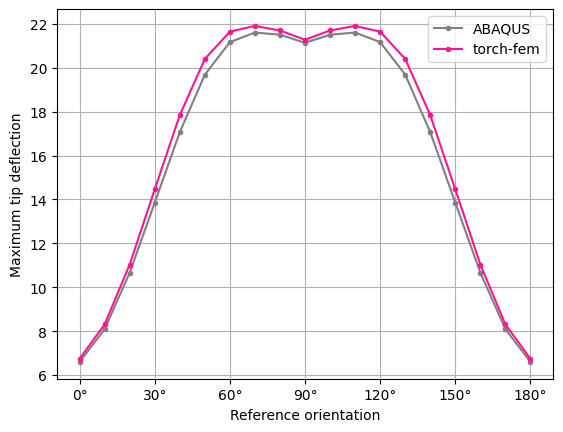

In [6]:
plt.plot(angles, abq_deflection, ".-", color="gray", label="ABAQUS")
plt.plot(angles, deflections, ".-", color="deeppink", label="torch-fem")
plt.xlabel("Reference orientation")
plt.ylabel("Maximum tip deflection")
plt.grid(True)
plt.legend()
plt.xticks(range(0, 181, 30), [f"{t}°" for t in range(0, 181, 30)])
plt.show()